In [2]:
# ============================================================
# 말벌 탐지
# ============================================================
# 데이터 구조:
#   ./audio/
#       No_Hornet/
#           *.wav
#       Hornet/
#           *.wav


# 목표:
#   1) 오디오 파일 읽기
#   2) waveplot 시각화
#   3) FFT 시각화
#   4) Spectrogram 생성 및 이미지 저장
#   5) CNN 분류 모델 학습
#   6) 성능 평가
#   7) 신규 오디오 예측 (절대경로 입력)
#   8) 예측 결과 시각화
#   9) 에러 방지 로직 반영

# 학습 데이터 :
# 기타 잡음은 고려 안했음, 필터링때 노이즈 제외될것으로 기대
# X = { 꿀벌, 꿀벌+꿀벌, 꿀벌+말벌, 말벌 }
# y = { 말벌없음 | 말벌있음 }

# 모델 :
# - CNN+Attention
# Mel-spectrogram (연속 윈도우)
#    -> multi resolution 입력, low-high
#    → CNN (local feature 추출)
#    → Temporal Attention (말벌 등장 시점에 집중)
#    → sigmoid 이진 분류
#         ├── 0: 꿀벌/잡음
#         └── 1: 말벌 감지!

In [3]:
# ------------------------------------------------------------
# 1. 필수 라이브러리 import
# ------------------------------------------------------------

# 운영체제 수준의 파일 경로 처리, 디렉토리 존재 여부 검사, 파일명 분리 등에 사용
import os

# 와일드카드 패턴(예: *.mp3, *.png)으로 파일 목록을 수집할 때 사용.
import glob

# 데이터 셔플 시 난수 기반 순서를 생성하기 위해 사용.
import random

# 폴더 전체 삭제, 파일 복사 등 파일 시스템 작업에 사용
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

# 오디오 로딩, STFT, mel spectrogram, dB 변환 등 오디오 DSP 전처리 핵심 라이브러리
import librosa

# librosa 기반 파형/스펙트로그램 표시용 보조 시각화 모듈
import librosa.display

# 저장된 spectrogram 이미지를 읽고, RGB 변환 및 크기 통일에 사용
from PIL import Image


from sklearn.metrics import classification_report, confusion_matrix 
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from scipy.signal import butter, filtfilt
from sklearn.metrics import accuracy_score



SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

import warnings
warnings.filterwarnings('ignore')

D:\Works\khivemind\.venv\lib\site-packages\google\api_core\_python_version_support.py:263: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [4]:
# ------------------------------------------------------------
# 2. 기본 경로 및 전역 하이퍼파라미터 설정
# ------------------------------------------------------------

BASE_DIR = os.getcwd()                                         # Root DIR 설정 
AUDIO_DIR = os.path.join(BASE_DIR, "audio")                    # 오디오 파일이 저장된 루트 폴더

SPEC_DIR = os.path.join(BASE_DIR, "spectrogram_data")          # 오디오를 이미지로 변환하여 저장할 루트 폴더
SPLIT_DIR = os.path.join(BASE_DIR, "spectrogram_split")        # CNN 학습용으로 train/val/test 구조로 나누어 저장 루트 폴더

BEST_MODEL_PATH = os.path.join(BASE_DIR, "hornet_cnn_sigmoid_model.keras")          # 최종 학습 모델 저장 경로
TEMP_PREDICT_IMAGE_PATH = os.path.join(BASE_DIR, "temp_predict_spectrogram.png")     # 신규 예측시 임시로 스펙트로그램 이미지를 저장할 경로

CLASSES = ["Normal","Hornet"]  # 분류 대상 클래스는 폴더명과 일치하도록 정의


# CNN 입력 이미지 높이, 너비
IMG_HEIGHT = 224
IMG_WIDTH = 224

# signal processing 파라미터 설정
SR = 44100                               # 샘플링 주파수
DURATION = 2.0                          # 오디오 길이 (초단위)
SAMPLES_PER_TRACK = SR * DURATION       # 1개 오디오 샘플당 기대되는 총 샘플 수
N_FFT = 4096                            # 멜 스펙트로그램 생성 시, 사용할 FFT 윈도우 길이
HOP_LENGTH = 256                        # 프레임 간 hop 크기 (값이 작을수록 시간 해상도 증가)
N_MELS = 126                            # mel filter bank 개수 (너무 작으면 정보 깨지고, 너무 크면 이미지 복잡해짐)

# bandwith filter
FMIN = 100                  # 100 Hz
FMAX = 1000                 # 1000 Hz

BATCH_SIZE = 16                         # 미니배치 크기
EPOCHS = 20                             # 반복 학습 수

In [5]:
# ------------------------------------------------------------
# 3. 유효성 검사 및 공통 유틸리티 함수
# ------------------------------------------------------------

def ensure_directory_exists(dir_path):
    """
    지정한 디렉토리가 존재하지 않으면 생성
    """
    os.makedirs(dir_path, exist_ok=True)


def validate_audio_directory_structure(audio_dir, classes):
    """
    audio 폴더와 클래스별 하위 폴더가 존재하는지 확인
    """
    if not os.path.exists(audio_dir):
        raise FileNotFoundError(f"[오류] audio 루트 폴더를 찾을 수 없습니다: {audio_dir}")

    for cls in classes:
        class_dir = os.path.join(audio_dir, cls)
        if not os.path.exists(class_dir):
            raise FileNotFoundError(f"[오류] 클래스 폴더가 없습니다: {class_dir}")


def count_audio_files(audio_dir, classes, extension="*.mp3"):
    """
    클래스별 오디오 파일 개수를 집계하여 dict 형태로 반환
    """
    counts = {}
    for cls in classes:
        pattern = os.path.join(audio_dir, cls, extension)
        counts[cls] = len(glob.glob(pattern))
    return counts


def validate_minimum_files_per_class(file_counts, minimum_count=3):
    """
    각 클래스에 최소 개수 이상의 파일이 존재하는지 검증
    """
    for cls, count in file_counts.items():
        if count < minimum_count:
            raise ValueError(
                f"[오류] 클래스 '{cls}'의 파일 수가 너무 적습니다. "
                f"최소 {minimum_count}개 이상 필요하지만 현재 {count}개입니다."
            )


def safe_remove_path(path):
    """
    파일 또는 디렉토리가 존재할 때만 삭제
    """
    if os.path.isdir(path):
        shutil.rmtree(path)
    elif os.path.isfile(path):
        os.remove(path)


def print_section_title(title):
    """
    노트북에서 섹션 구분이 명확하게 보이도록 제목 출력
    """
    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)


데이터 폴더 및 파일 개수 확인
원본 오디오 루트 경로: D:\Works\khivemind\feature_engineering\audio
스펙트로그램 저장 경로: D:\Works\khivemind\feature_engineering\spectrogram_data
분할 데이터 저장 경로: D:\Works\khivemind\feature_engineering\spectrogram_split
    Class  Count
0  Normal    200
1  Hornet    201


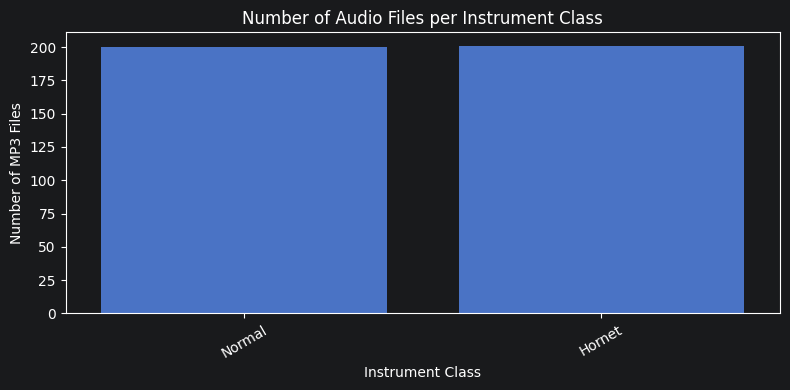

In [7]:
# ------------------------------------------------------------
# 4. 데이터 폴더 구조 및 파일 개수 확인
# ------------------------------------------------------------

# audio 폴더와 클래스별 하위 폴더가 실제로 존재하는지 검증
validate_audio_directory_structure(AUDIO_DIR, CLASSES)

# 클래스별 wav 개수를 집계
file_counts = count_audio_files(AUDIO_DIR, CLASSES, extension="*.wav")

# 각 클래스가 최소한의 샘플 수를 갖는지 확인
validate_minimum_files_per_class(file_counts, minimum_count=3)

# 집계 결과를 데이터프레임으로 변환
file_counts_df = pd.DataFrame(list(file_counts.items()), columns=["Class", "Count"])

# 현재 데이터 구성 상황을 출력
print_section_title("데이터 폴더 및 파일 개수 확인")
print("원본 오디오 루트 경로:", AUDIO_DIR)
print("스펙트로그램 저장 경로:", SPEC_DIR)
print("분할 데이터 저장 경로:", SPLIT_DIR)
print(file_counts_df)

# 클래스별 데이터 불균형 여부를 시각적으로 확인
plt.figure(figsize=(8, 4))
sns.barplot(data=file_counts_df, x="Class", y="Count")
plt.title("Number of Audio Files per Instrument Class")
plt.xlabel("Instrument Class")
plt.ylabel("Number of MP3 Files")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [8]:
# ------------------------------------------------------------
# 5. 오디오 로드 함수 정의
# ------------------------------------------------------------
def load_audio_file(file_path, sr=SR, duration=DURATION):
    """
    오디오 파일을 모노 신호로 읽고, 지정 길이로 고정한다.

    설계 의도:
    - 모델 입력 일관성을 위해 모든 오디오 길이를 동일하게 맞춘다.
    - 너무 짧은 파일은 zero-padding한다.
    - 너무 긴 파일은 앞부분을 사용한다.
    - 실습/강의 환경에서 mp3 코덱 또는 파일 경로 문제를 조기에 감지할 수 있도록 예외를 명확히 전달한다.
    """

    # 입력 경로가 문자열인지 확인한다.
    if not isinstance(file_path, str):
        raise TypeError(f"[오류] file_path는 문자열이어야 합니다. 현재 타입: {type(file_path)}")

    # 실제 파일 존재 여부를 먼저 확인한다.
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"[오류] 오디오 파일이 존재하지 않습니다: {file_path}")

    # 파일 확장자를 확인한다. 이 실습은 mp3를 기본으로 가정하지만 wav 등으로 확장 가능하다.
    valid_exts = [".mp3", ".wav", ".flac", ".ogg", ".m4a"]
    ext = os.path.splitext(file_path)[1].lower()
    if ext not in valid_exts:
        raise ValueError(f"[오류] 지원하지 않는 오디오 확장자입니다: {ext}")

    try:
        # mono=True는 스테레오 입력을 단일 채널로 평균/변환하여 처리 일관성을 확보한다.
        y, sr = librosa.load(file_path, sr=sr, mono=True)
    except Exception as e:
        raise RuntimeError(f"[오류] 오디오 로드 실패: {file_path}\n원인: {e}")

    # 비어 있는 배열이 들어오면 이후 FFT/STFT에서 실패하므로 사전 차단한다.
    if y is None or len(y) == 0:
        raise ValueError(f"[오류] 오디오 데이터가 비어 있습니다: {file_path}")

    # 목표 샘플 길이를 계산한다.
    target_length = int(sr * duration)

    # 길이가 짧으면 뒤를 0으로 패딩하여 고정 길이를 맞춘다.
    if len(y) < target_length:
        pad_width = target_length - len(y)
        y = np.pad(y, (0, pad_width), mode='constant')

    # 길이가 길면 앞부분만 사용한다.
    else:
        y = y[:target_length]

    return y, sr

def bandpass_filter(y, sr, lowcut, highcut, order=5):
    nyquist = 0.5 * sr
    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype='band')
    y_filtered = filtfilt(b, a, y)

    return y_filtered

In [9]:
# ------------------------------------------------------------
# 6. 샘플 오디오 파일 1개 선택 및 기본 분석
# ------------------------------------------------------------
# 데이터 시각화 예제로 사용할 첫 번째 샘플 파일을 찾는다.
sample_file = None
sample_class = None

# audio 디렉토리에서 첫번째 오디오 파일
for cls in CLASSES:
    pattern = os.path.join(AUDIO_DIR, cls, "*.wav")
    files = glob.glob(pattern)
    if len(files) > 0:
        sample_file = files[0]
        sample_class = cls
        break

# 샘플 파일을 하나도 찾지 못한 경우 즉시 에러를 발생시킴
if sample_file is None:
    raise FileNotFoundError("[오류] 샘플로 사용할 mp3 파일을 찾지 못했습니다.")

# 샘플 파일을 로드
y_sample, sr_sample = load_audio_file(sample_file)


y_sample = bandpass_filter(y_sample, sr_sample, FMIN, FMAX)

# 샘플 파일 정보를 출력
print_section_title("샘플 오디오 정보")
print("샘플 클래스:", sample_class)
print("샘플 파일:", sample_file)
print("샘플링 주파수:", sr_sample)
print("총 샘플 수:", len(y_sample))
print("총 길이(초):", len(y_sample) / sr_sample)


샘플 오디오 정보
샘플 클래스: Normal
샘플 파일: D:\Works\khivemind\feature_engineering\audio\Normal\output_Bee_0_Bee_0_0000.wav
샘플링 주파수: 44100
총 샘플 수: 88200
총 길이(초): 2.0


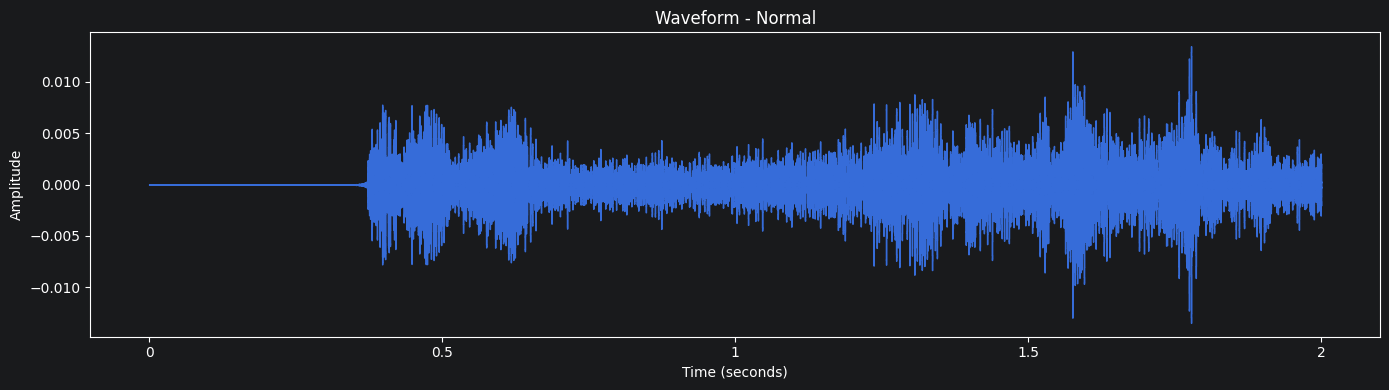

In [10]:
# ------------------------------------------------------------
# 7. 샘플 오디오 waveplot 시각화
# ------------------------------------------------------------

# 파형은 시간축에서 신호 진폭이 어떻게 변하는지 보여주는 가장 기본적인 표현
# onset, silence, envelope 등 거시적 구조를 확인하는 데 유용
plt.figure(figsize=(14, 4))
librosa.display.waveshow(y_sample, sr=sr_sample)
plt.title(f"Waveform - {sample_class}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

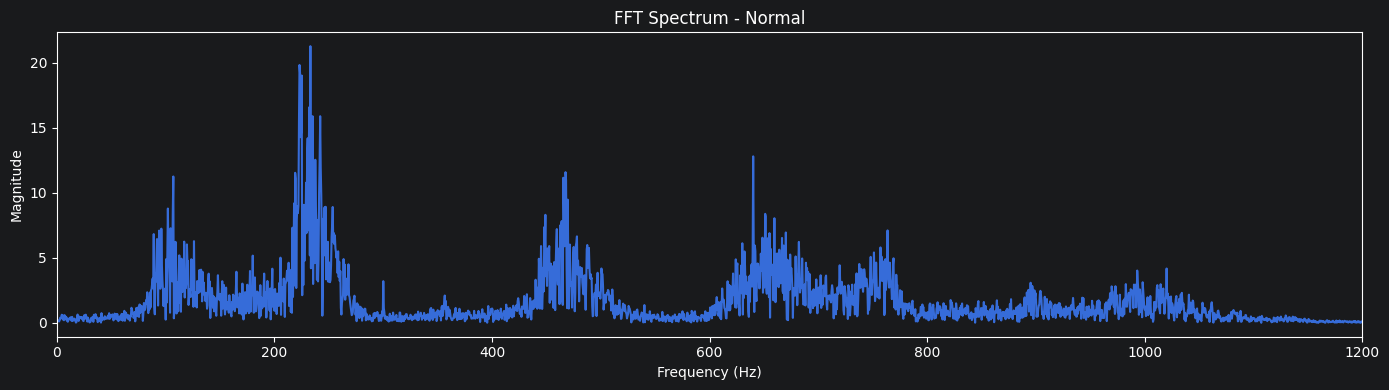

In [11]:
# ------------------------------------------------------------
# 8. 샘플 오디오 FFT 시각화
# ------------------------------------------------------------

# FFT는 시간영역 신호를 주파수영역으로 투영하여 어떤 주파수 성분이 강한지 확인
fft_sample = np.fft.fft(y_sample)

# 복소수 푸리에 계수의 절댓값을 취해 magnitude spectrum을 계산
magnitude_sample = np.abs(fft_sample)

# 각 인덱스가 실제 어떤 주파수(Hz)에 대응하는지 계산
freqs_sample = np.fft.fftfreq(len(magnitude_sample), d=1 / sr_sample)

# 실수 신호 FFT는 음수 주파수 구간이 대칭이므로 양수 영역만 사용
positive_freqs_sample = freqs_sample[:len(freqs_sample) // 2]
positive_magnitude_sample = magnitude_sample[:len(magnitude_sample) // 2]

# 저주파~중주파 영역을 주로 보기 위해 x축을 적절히 제한
plt.figure(figsize=(14, 4))
plt.plot(positive_freqs_sample, positive_magnitude_sample)
plt.title(f"FFT Spectrum - {sample_class}")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 1200)
plt.tight_layout()
plt.show()

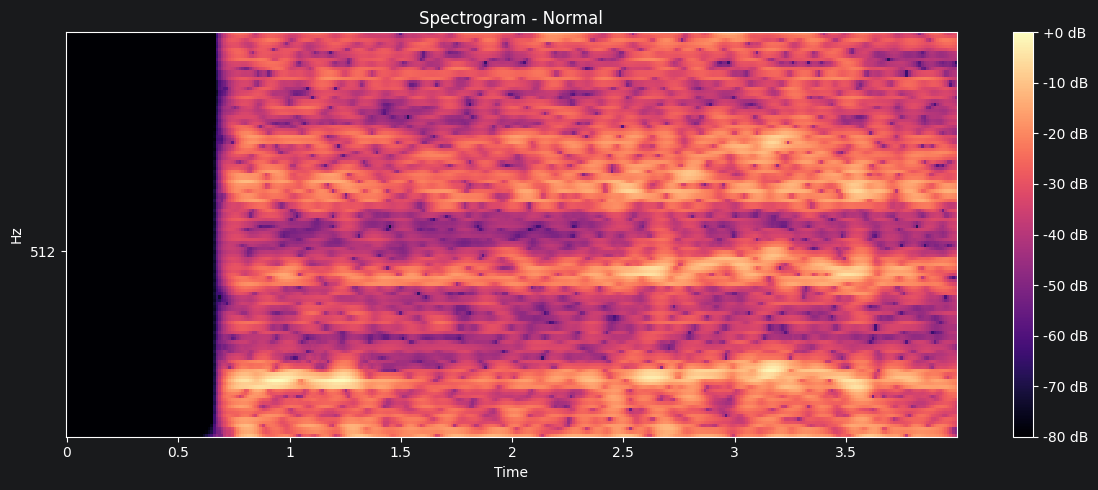

In [12]:
# ------------------------------------------------------------
# 9. 샘플 오디오 STFT Spectrogram 시각화
# ------------------------------------------------------------

 # 오디오 로드

# high mel spectrogram을 계산
mel_spec = librosa.feature.melspectrogram(
    y=y_sample,
    sr=sr_sample,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    power=2.0,
    fmin=FMIN,
    fmax=FMAX
)
# power spectrogram을 dB로 변환
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)


# 로그 주파수축 spectrogram을 그린다.
plt.figure(figsize=(12, 5))
librosa.display.specshow(
    mel_spec_db,
    sr=sr_sample,
    x_axis='time',
    y_axis='mel',
    cmap='magma',
    fmin=FMIN,
    fmax=FMAX
)
plt.colorbar(format='%+2.0f dB')
plt.title(f"Spectrogram - {sample_class}")
plt.tight_layout()
plt.show()



In [13]:
# ------------------------------------------------------------
# 10. Spectrogram 이미지 저장 함수
# ------------------------------------------------------------
def save_spectrogram_image(audio_path, save_path, sr=SR, duration=DURATION):
    # 저장 경로의 상위 폴더가 존재하도록 보장
    save_dir = os.path.dirname(save_path)

    # save_path가 현재 작업 디렉토리 바로 아래 파일일 경우 dirname이 빈 문자열일 수 있다.
    if save_dir != "":
        ensure_directory_exists(save_dir)

    # 오디오 로드
    y, sr = load_audio_file(audio_path, sr=sr, duration=duration)

    # bandwith filter pass
    y = bandpass_filter(y, sr, FMIN, FMAX)

    # mel spectrogram을 계산
    mel_spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        power=2.0,
        fmin=FMIN,
        fmax=FMAX
    )

    # power spectrogram을 dB로 변환
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    fig = plt.figure(figsize=(4, 4))

    # 축/눈금 없이 순수한 스펙트럼 패턴만 저장되도록 그린다.
    librosa.display.specshow(
        mel_spec_db,
        sr=sr,
        hop_length=HOP_LENGTH,
        x_axis=None,
        y_axis=None,
        cmap='magma',
        fmin=FMIN,
        fmax=FMAX
    )

    # CNN이 의미 없는 축 텍스트를 학습하지 않도록 축을 제거
    plt.axis('off')

    # 저장 시 여백을 최소화
    plt.tight_layout(pad=0)

    # PNG로 저장한다.
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0)

    # 메모리 정리를 위해 figure를 닫는다.
    plt.close(fig)

    # 저장된 이미지를 열어 RGB 변환 후 입력 크기로 통일
    # bbox_inches='tight'로 저장하면 실제 픽셀 크기가 매번 조금씩 달라질 수 있으므로 후처리로 정규화
    img = Image.open(save_path).convert("RGB")
    img = img.resize((IMG_WIDTH, IMG_HEIGHT))
    img.save(save_path)

In [14]:
# ------------------------------------------------------------
# 11. 전체 오디오 파일 -> Spectrogram 이미지 생성
# ------------------------------------------------------------
# 전체 오디오 파일 -> Spectogram 이미지 생성

safe_remove_path(SPEC_DIR)

ensure_directory_exists(SPEC_DIR)

print_section_title('오디오 파일을 스펙트로그램 이미지로 변환 중...')

# 각 클래스별로 오디오 파일을 읽어서 스펙트로그램 이미지로 저장
for cls in CLASSES:
    class_audio_dir = os.path.join(AUDIO_DIR, cls)
    class_spec_dir = os.path.join(SPEC_DIR, cls)

    # 클래스 별 스펙트로그램 저장 폴더 생성
    ensure_directory_exists(class_spec_dir)

    # 해당 클래스의 모든 mp3 파일을 가져오기
    audio_files = glob.glob(os.path.join(class_audio_dir, '*.wav'))

    # 처리 현황을 출력
    print(f'{cls}: {len(audio_files)}개 파일 처리 중...')

    # 각 파일을 spectrogram 으로 변환
    for audio_file in audio_files:
        base_name = os.path.splitext(os.path.basename(audio_file))[0]
        save_path = os.path.join(class_spec_dir, f'{base_name}.png')
        save_spectrogram_image(audio_file, save_path)

print('스펙토그램 이미지 생성 완료')


오디오 파일을 스펙트로그램 이미지로 변환 중...
Normal: 200개 파일 처리 중...
Hornet: 201개 파일 처리 중...
스펙토그램 이미지 생성 완료


In [15]:
# ------------------------------------------------------------
# 12. train / val / test 분할 함수
# ------------------------------------------------------------

def split_dataset_to_folders(source_dir, target_dir, classes, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    """
    spectrogram 이미지를 클래스별 train/val/test 폴더 구조로 분할
    """

    # 기존 split 폴더를 삭제
    safe_remove_path(target_dir)

    # 비율의 합이 1인지 검증
    if abs(train_ratio + val_ratio + test_ratio - 1.0) >= 1e-6:
        raise ValueError("[오류] train_ratio + val_ratio + test_ratio의 합은 반드시 1이어야 함")

    for cls in classes:
        class_dir = os.path.join(source_dir, cls)

        # 원본 클래스 이미지가 존재하는지 확인
        if not os.path.exists(class_dir):
            raise FileNotFoundError(f"[오류] spectrogram 클래스 폴더가 없습니다: {class_dir}")

        image_files = glob.glob(os.path.join(class_dir, "*.png"))

        # 클래스별 이미지가 없으면 학습 불가이므로 중단
        if len(image_files) == 0:
            raise ValueError(f"[오류] 클래스 '{cls}'의 spectrogram 이미지가 없습니다.")

        # 무작위 셔플 후 분할
        random.shuffle(image_files)

        n_total = len(image_files)
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)

        train_files = image_files[:n_train]
        val_files = image_files[n_train:n_train + n_val]
        test_files = image_files[n_train + n_val:]

        # split별 폴더를 생성
        for split_name in ["train", "val", "test"]:
            ensure_directory_exists(os.path.join(target_dir, split_name, cls))

        # 복사 보조 함수
        def copy_files(files, split_name):
            for f in files:
                dst = os.path.join(target_dir, split_name, cls, os.path.basename(f))
                shutil.copy2(f, dst)

        copy_files(train_files, "train")
        copy_files(val_files, "val")
        copy_files(test_files, "test")

        print(f"{cls} -> train:{len(train_files)}, val:{len(val_files)}, test:{len(test_files)}")


def validate_split_dataset(target_dir, classes):
    """
    split 이후 각 train/val/test/class 폴더에 최소 1개 이상의 이미지가 있는지 검증한다.
    """
    print_section_title("분할 데이터셋 검증")
    for split_name in ["train", "val", "test"]:
        print(f"[{split_name}]")
        for cls in classes:
            class_dir = os.path.join(target_dir, split_name, cls)
            count = len(glob.glob(os.path.join(class_dir, "*.png")))
            print(f"  {cls}: {count}개")
            if count == 0:
                raise ValueError(
                    f"[오류] {split_name}/{cls} 폴더에 이미지가 없습니다. "
                    f"클래스별 샘플 수가 너무 적거나 분할 비율 조정이 필요합니다."
                )

In [16]:
# ------------------------------------------------------------
# 13. 데이터셋 분할 수행
# ------------------------------------------------------------

print_section_title("train / val / test 분할 시작")
split_dataset_to_folders(SPEC_DIR, SPLIT_DIR, CLASSES, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15)
validate_split_dataset(SPLIT_DIR, CLASSES)
print("데이터 분할 완료")


train / val / test 분할 시작
Normal -> train:140, val:30, test:30
Hornet -> train:140, val:30, test:31

분할 데이터셋 검증
[train]
  Normal: 140개
  Hornet: 140개
[val]
  Normal: 30개
  Hornet: 30개
[test]
  Normal: 30개
  Hornet: 31개
데이터 분할 완료


In [19]:
# ------------------------------------------------------------
# 14. ImageDataGenerator 설정
# ------------------------------------------------------------
# 학습 데이터는 약한 수준의 augmentation을 적용하여 일반화 성능을 높임
# spectrogram은 일반 사진과 의미 체계가 다르므로 회전/이동/확대 범위를 매우 작게 유지

train_datagen = ImageDataGenerator(
    rescale=1/255,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
#    rotation_range=3
)

val_test_datagen = ImageDataGenerator(rescale=1/255)

train_generator = train_datagen.flow_from_directory(
    directory=os.path.join(SPLIT_DIR, 'train'),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=CLASSES,
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    directory=os.path.join(SPLIT_DIR, 'val'),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=CLASSES,
    shuffle=False,
)

test_generator = val_test_datagen.flow_from_directory(
    directory=os.path.join(SPLIT_DIR, 'test'),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=CLASSES,
    shuffle=False,
)

# 클래스 인덱스 매핑 출력
print_section_title('클래스 인덱스 매핑')
print(train_generator.class_indices)
# index -> class 이름 역매핑을 미리 만들어줌
idx_to_class = {v : k for k, v in train_generator.class_indices.items()}
print('역매핑:', idx_to_class)


Found 280 images belonging to 2 classes.
Found 60 images belonging to 2 classes.
Found 61 images belonging to 2 classes.

클래스 인덱스 매핑
{'Normal': 0, 'Hornet': 1}
역매핑: {0: 'Normal', 1: 'Hornet'}


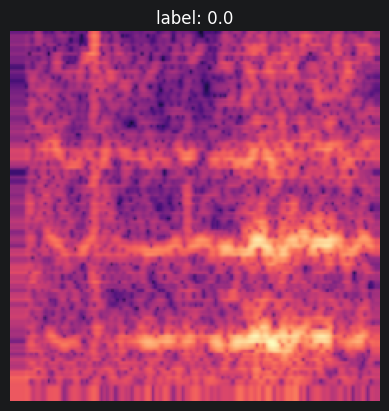

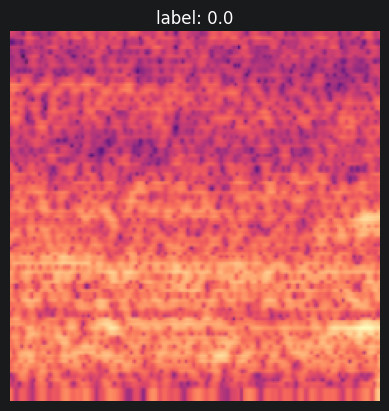

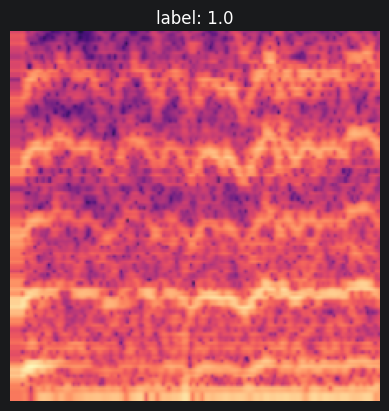

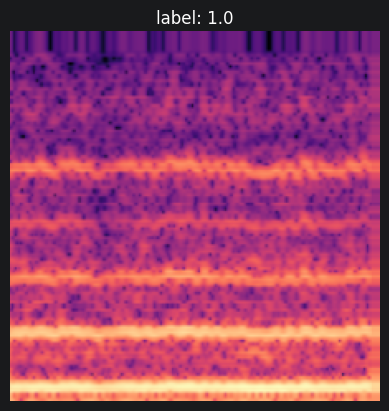

In [20]:
# train_generator 확인

x_batch, y_batch = next(train_generator)

for i in range(4):
    plt.imshow(x_batch[i])
    plt.title(f"label: {y_batch[i]}")
    plt.axis('off')
    plt.show()

In [23]:
class TemporalAttention(layers.Layer):
    """
    시간축(width) 방향으로 attention weight를 계산하여
    중요한 시간 구간에 집중하도록 유도하는 레이어.

    - GlobalAveragePooling으로 주파수 축을 압축
    - FC → softmax로 각 time step의 중요도(weight) 산출
    - 원본 feature map에 weight를 곱해 중요 구간 강조
    """

    def __init__(self, **kwargs):
        super(TemporalAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        # input_shape: (batch, height, width, channels)
        self.time_steps = input_shape[2]  # width = 시간 축
        self.channels   = input_shape[3]

        # 시간 축 attention score 생성용 FC
        self.fc = layers.Dense(self.time_steps, activation='softmax')
        super(TemporalAttention, self).build(input_shape)

    def call(self, x):
        # 1) 주파수(height) 축 평균 → (batch, width, channels)
        avg = tf.reduce_mean(x, axis=1)

        # 2) 채널 평균 → (batch, width)
        avg = tf.reduce_mean(avg, axis=-1)

        # 3) FC → attention weights (batch, time_steps), softmax 합산=1
        attn_weights = self.fc(avg)           # (batch, time_steps)

        # 4) 브로드캐스트를 위해 차원 확장 (batch, 1, time_steps, 1)
        attn_weights = tf.reshape(attn_weights, (-1, 1, self.time_steps, 1))

        # 5) 원본 feature map에 element-wise 곱 (중요 시간대 강조)
        return x * attn_weights

    def get_config(self):
        return super(TemporalAttention, self).get_config()

In [24]:
# ------------------------------------------------------------
# 15. CNN 모델 정의
# ------------------------------------------------------------

# 입력 shape는 고정된 spectrogram RGB 이미지 크기
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)

# Sequential 모델 생성
model = models.Sequential()

# Block 1:
# 저수준 edge/texture 패턴을 추출
model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape))
model.add(layers.MaxPooling2D((2, 2)))

# Block 2:
# 더 복잡한 주파수 리지, 하모닉 구조, 시간-주파수 패턴을 학습
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

# Block 3:
# 중간 수준의 패턴 조합을 표현
model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

# Block 4:
# 클래스 구분력이 높은 상위 수준 특성을 형성
model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

# ★ Temporal Attention
# Block 4 이후 feature map에서 말벌 소리가 나타나는
# 시간 구간에 선택적으로 집중
# model.add(TemporalAttention())

# 2차원 feature map을 1차원 벡터로 변환
model.add(layers.Flatten())

# Dense layer는 학습된 로컬 패턴들을 종합하여 클래스 결정 경계를 형성
model.add(layers.Dense(256, activation='relu'))

# Dropout은 특정 뉴런 의존도를 줄여 과적합방지
model.add(layers.Dropout(0.5))

# 최종 출력층은 hornet 1, no hornet 0 확률 분포를 생성
model.add(layers.Dense(1, activation='sigmoid'))

# 이진분류로 binary_crossentropy를 사용
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 모델 구조를 출력
print_section_title("CNN 모델 구조")
model.summary()


CNN 모델 구조


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,233,985 (50.48 MB)

 Trainable params: 13,233,985 (50.48 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# ------------------------------------------------------------
# 16. 학습 콜백 설정
# ------------------------------------------------------------

# validation loss가 일정 epoch 동안 개선되지 않으면 학습을 조기 종료
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# validation accuracy가 최고일 때의 모델을 자동 저장
checkpoint = ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [ ]:
# ------------------------------------------------------------
# 17. 모델 학습
# ------------------------------------------------------------


history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/20
10/18 ━━━━━━━━━━━━━━━━━━━━ 3s 494ms/step - accuracy: 0.5098 - loss: 1.2022

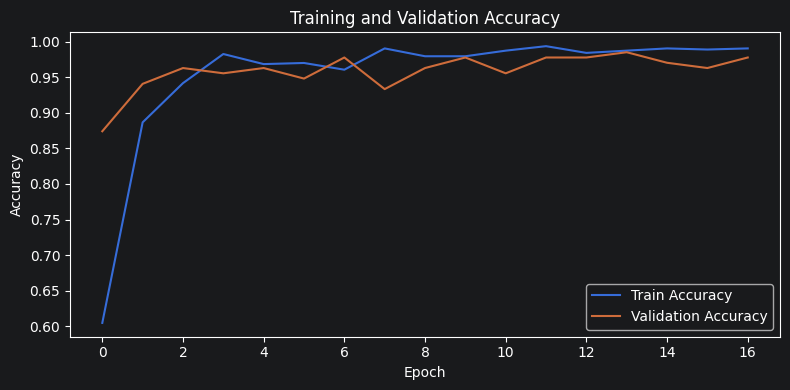

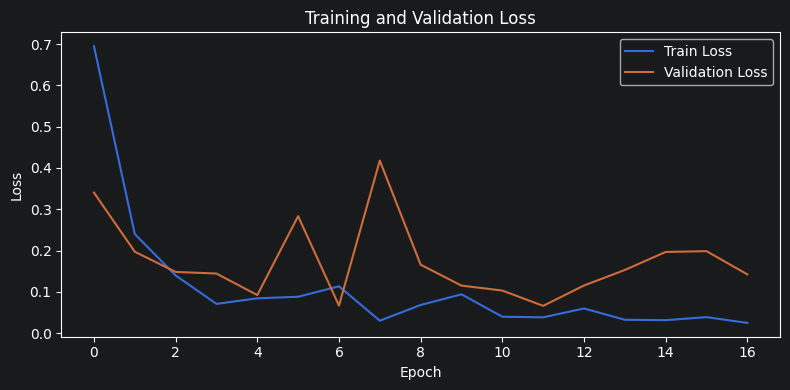

In [45]:
# ------------------------------------------------------------
# 18. 학습 과정 시각화
# ------------------------------------------------------------

plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

테스트 손실:  0.05288633331656456
테스트 정확도:  0.9375
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
정확도: 0.9375
confusion matrix: 
 [[15  1]
 [ 0  0]]
분류 리포트 :
               precision    recall  f1-score   support

         0.0       1.00      0.94      0.97        16
         1.0       0.00      0.00      0.00         0

    accuracy                           0.94        16
   macro avg       0.50      0.47      0.48        16
weighted avg       1.00      0.94      0.97        16



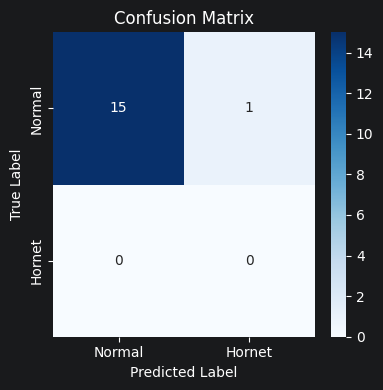

In [89]:
# ------------------------------------------------------------
# 19. 테스트셋 분류 리포트 및 Confusion Matrix
# ------------------------------------------------------------

# test_generator 확인
x_batch, y_batch = next(test_generator)

#print (y_batch[:10])

test_loss, test_acc = model.evaluate(x_batch, y_batch, verbose=0)
# 평가 결과 출력
print('테스트 손실: ', test_loss)
print('테스트 정확도: ', test_acc)

# 예측 확률
y_prob = model.predict(x_batch)

# 확률을 0 또는 1 클래스로 변환
y_pred = (y_prob >= 0.5).astype(int).flatten()

# 정확도 계산
acc = accuracy_score(y_batch, y_pred)

# confusion matrix 계산
cm = confusion_matrix(y_batch, y_pred)

# 분류 리포트 출력
print('정확도:', acc)
print('confusion matrix: \n', cm)
print('분류 리포트 :\n', classification_report(y_batch, y_pred))


plt.figure(figsize=(4, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASSES,
    yticklabels=CLASSES
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()



In [120]:
# ------------------------------------------------------------
# 20. 예측용 오디오 분석/시각화 함수
# ------------------------------------------------------------

def visualize_audio_analysis(audio_path, predicted_class=None, prob=None):
    """
    신규 입력 오디오에 대해 waveplot, FFT, spectrogram을 순차적으로 시각화
    """

    # 오디오를 로드
    y, sr = load_audio_file(audio_path)


    # bandwith filter pass
    y = bandpass_filter(y, sr, FMIN, FMAX)

    # 파일명만 표시용으로 추출
    file_name = os.path.basename(audio_path)

    # 1) waveplot 시각화
    plt.figure(figsize=(14, 4))
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Input Audio Waveform - {file_name}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

    # 2) FFT 시각화
    fft_vals = np.fft.fft(y)
    magnitude = np.abs(fft_vals)
    freqs = np.fft.fftfreq(len(magnitude), d=1 / sr)
    positive_freqs = freqs[:len(freqs) // 2]
    positive_magnitude = magnitude[:len(magnitude) // 2]

    plt.figure(figsize=(14, 4))
    plt.plot(positive_freqs, positive_magnitude)
    plt.title(f"Input Audio FFT Spectrum - {file_name}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.xlim(0, 1200)
    plt.tight_layout()
    plt.show()

    # 3) Spectrogram 시각화
    stft = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)
    spectrogram = np.abs(stft)
    spectrogram_db = librosa.amplitude_to_db(spectrogram, ref=np.max)

    plt.figure(figsize=(12, 5))
    librosa.display.specshow(
        spectrogram_db,
        sr=sr,
        hop_length=HOP_LENGTH,
        x_axis='time',
        y_axis='log'
    )
    plt.colorbar(format='%+2.0f dB')
    if predicted_class is None:
        plt.title(f"Input Audio Spectrogram - {file_name}")
    else:
        plt.title(f"Input Audio Spectrogram - {file_name}\nPredicted: {predicted_class}")
    plt.tight_layout()
    plt.show()

    if prob is not None:
        probs = [1 - prob.item(), prob.item()]
        plt.figure()
        plt.bar(CLASSES, probs)
        plt.ylim(0, 1)
        plt.title("Prediction Probability")
        # 값 표시
        for i, v in enumerate(probs):
            plt.text(i, v + 0.02, f"{v:.4f}", ha='center')
        plt.show()


In [121]:
# ------------------------------------------------------------
# 21. 신규 오디오 예측 함수
# ------------------------------------------------------------

def predict_instrument_from_audio_absolute_path(audio_path, model, class_indices, save_temp_image=False):
    """
    절대경로로 지정한 신규 오디오 파일을 읽어와 CNN으로 예측한다.

    기능:
    - 입력 파일 유효성 검사
    - spectrogram 임시 이미지 생성
    - 모델 추론
    - 예측 클래스 및 확률 반환
    - 입력 오디오 waveplot / FFT / spectrogram / 확률 시각화 수행
    """

    # 입력값 타입 검증
    if not isinstance(audio_path, str):
        raise TypeError("[오류] audio_path는 문자열이어야 합니다.")

    # 절대경로인지 확인한다. 사용자 요청 조건을 강제하기 위한 검증.
    if not os.path.isabs(audio_path):
        raise ValueError(f"[오류] 신규 오디오 예측 경로는 절대경로여야 합니다: {audio_path}")

    # 실제 파일 존재 여부 확인
    if not os.path.exists(audio_path):
        raise FileNotFoundError(f"[오류] 신규 예측용 오디오 파일이 존재하지 않습니다: {audio_path}")

    # 모델 유효성 확인
    if model is None:
        raise ValueError("[오류] 학습된 모델이 없습니다.")

    # 클래스 인덱스 매핑 확인
    if not isinstance(class_indices, dict) or len(class_indices) == 0:
        raise ValueError("[오류] class_indices가 비어 있거나 유효하지 않습니다.")

    # 임시 spectrogram 이미지가 남아 있으면 삭제
    if os.path.exists(TEMP_PREDICT_IMAGE_PATH):
        os.remove(TEMP_PREDICT_IMAGE_PATH)

    # 신규 오디오를 spectrogram 이미지로 변환
    save_spectrogram_image(audio_path, TEMP_PREDICT_IMAGE_PATH)

    # 임시 이미지가 실제 생성되었는지 확인
    if not os.path.exists(TEMP_PREDICT_IMAGE_PATH):
        raise FileNotFoundError("[오류] 예측용 임시 spectrogram 이미지 생성에 실패했습니다.")

    # 저장된 이미지를 열어 RGB 변환
    img = Image.open(TEMP_PREDICT_IMAGE_PATH).convert("RGB")

    # 모델 입력 크기로 리사이즈
    img = img.resize((IMG_WIDTH, IMG_HEIGHT))

    # numpy 배열로 변환 후 0~1 범위로 정규화
    img_array = np.array(img).astype("float32") / 255.0

    # (H, W, C) -> (1, H, W, C)로 배치 축을 추가
    img_array = np.expand_dims(img_array, axis=0)

    # 모델 추론을 수행한다.
    new_prob = model.predict(img_array, verbose=0)[0]

    # 예측 확률값을 0/1로 변환
    new_pred = (new_prob >= 0.5).astype(int).flatten()

    # 예측 클래스 이름
    predicted_class = CLASSES[new_pred.item()]

    # 예측용 spectrogram 이미지 자체를 보여준다.
    plt.figure(figsize=(5, 5))
    plt.imshow(Image.open(TEMP_PREDICT_IMAGE_PATH))
    plt.title(f"Prediction Spectrogram\nPredicted: {predicted_class}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # 입력 오디오의 wave/FFT/spectrogram/확률을 함께 시각화
    visualize_audio_analysis(
        audio_path=audio_path,
        predicted_class=predicted_class,
        prob=new_prob
    )

    # 임시 저장을 원하지 않으면 삭제
    if not save_temp_image and os.path.exists(TEMP_PREDICT_IMAGE_PATH):
        os.remove(TEMP_PREDICT_IMAGE_PATH)

    return predicted_class, new_prob


신규 오디오 예측 준비
절대경로 입력 예시: D:\khivemind_project\audio\Normal\output_Bee_0_Bee_0_0000.wav


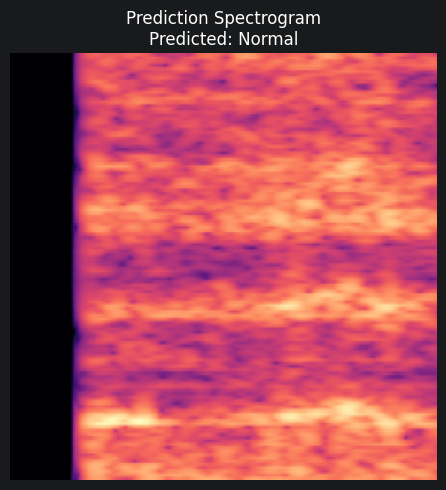

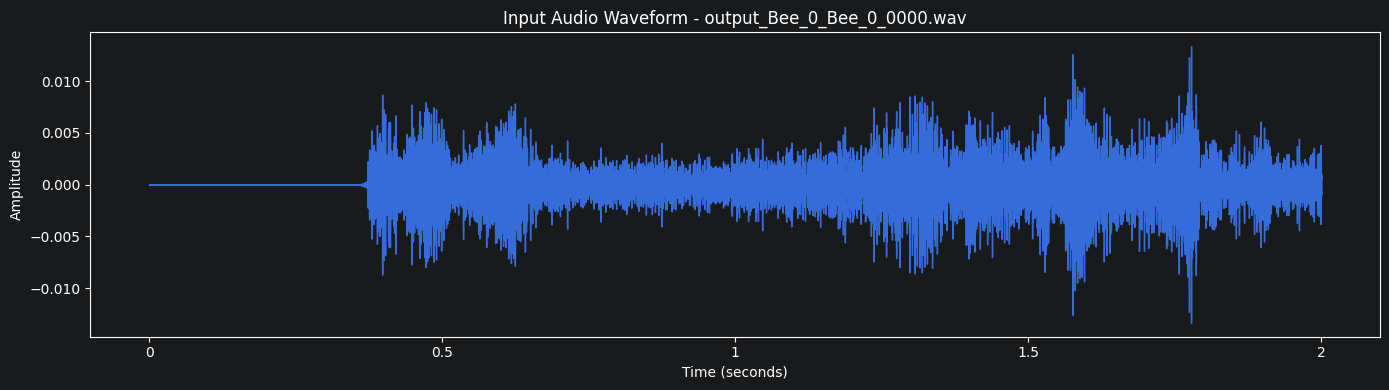

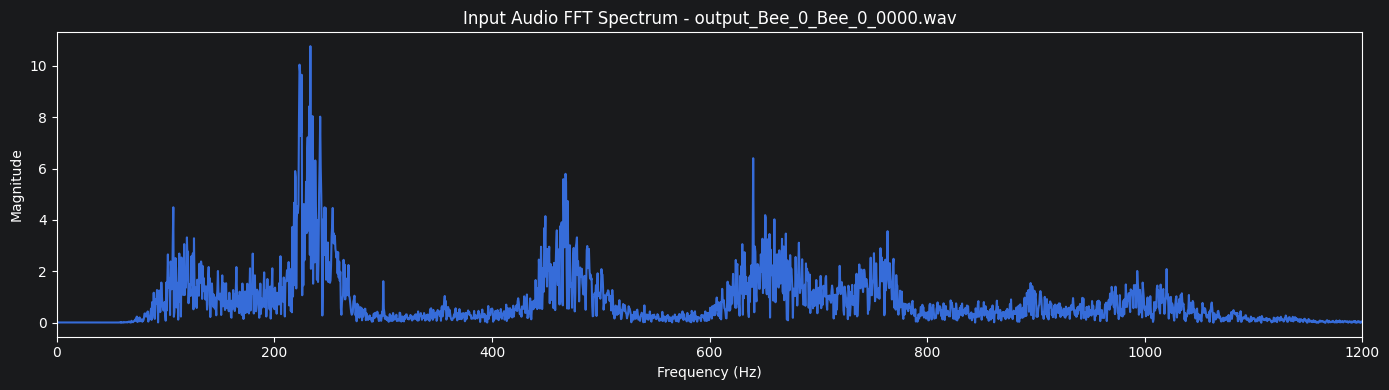

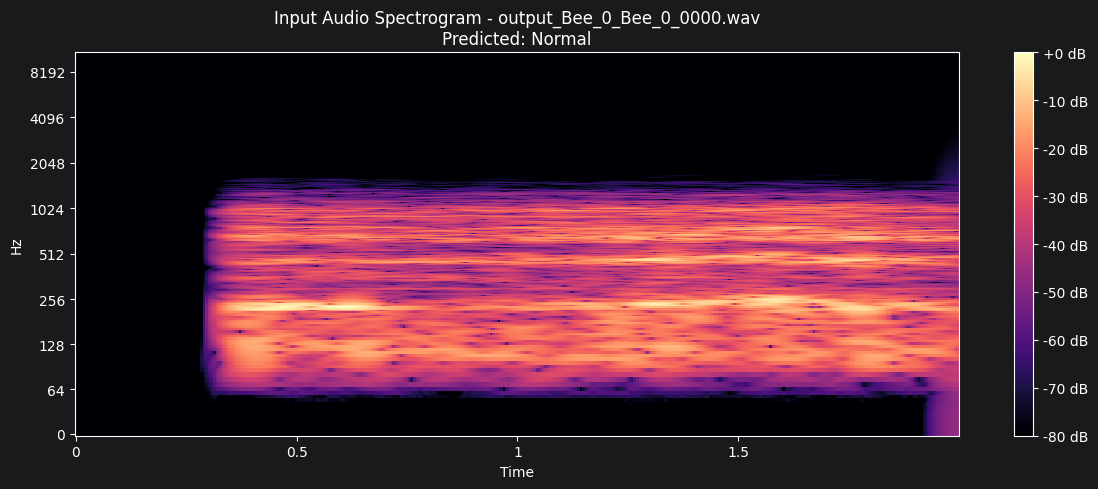

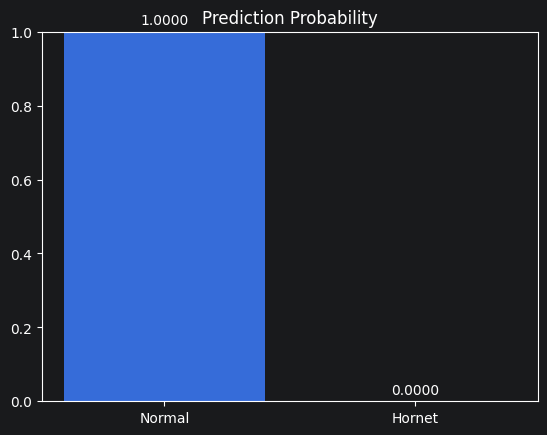


예측 클래스: Normal
Normal: 1.0000
Hornet: 0.0000


In [122]:
# ------------------------------------------------------------
# 22. 신규 오디오 절대경로 입력 예시
# ------------------------------------------------------------

# 아래 경로는 반드시 사용자의 실제 Windows 절대경로로 바꿔서 사용

NEW_AUDIO_ABSOLUTE_PATH = r'D:\khivemind_project\audio\Normal\output_Bee_0_Bee_0_0000.wav'

# 절대경로를 실제 값으로 수정한 뒤 아래 블록을 실행
# 존재하지 않는 예시 경로일 수 있으므로 자동 실행 전에 파일 존재 여부를 먼저 점검
print_section_title("신규 오디오 예측 준비")
print("절대경로 입력 예시:", NEW_AUDIO_ABSOLUTE_PATH)

if os.path.exists(NEW_AUDIO_ABSOLUTE_PATH):
    predicted_class, prob = predict_instrument_from_audio_absolute_path(
        audio_path=NEW_AUDIO_ABSOLUTE_PATH,
        model=model,
        class_indices=train_generator.class_indices,
        save_temp_image=False
    )

    print("\n예측 클래스:", predicted_class)

    print(f"Normal: {1-prob.item():.4f}")
    print(f"Hornet: {prob.item():.4f}")
else:
    print("NEW_AUDIO_ABSOLUTE_PATH를 실제 존재하는 절대경로로 수정한 뒤 예측 블록을 실행하세요.")

